# Identificación del riesgo de inundación por desbordamiento en Bogotá 
### Objetivo: realizar el análisis de riesgo de inundación y vulnerabilidad en tres fases: 
1. Delimitar zonas potencialmente inundables
2. Analizar la exposición de población y población vulnerable en zonas inundables
3. Índice de riesgo de inundación
#### Fuentes de información: Cuerpos de agua y Modelo Digital de Terreno (IDECA), Población e Índice de Pobreza Multidimensional a nivel de manzana del Censo de Población y Vivienda de 2018 (DANE)

In [1]:
# Importar librerías 
import geopandas as gpd
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import contextily as cx
import rasterio
import os
import whitebox
from rasterstats import zonal_stats
from pathlib import Path
from rasterio.plot import show
from rasterio.features import rasterize
from rasterio.mask import mask
from whitebox import WhiteboxTools
from shapely.geometry import Point
from matplotlib_scalebar.scalebar import ScaleBar

#### Rutas de trabajo 
Modificar según la ubicación local de los datos del usuario

In [2]:
# Ruta para los datos crudos: 
#root_folder=r"/notebooks/trabajo_final/datos"
root_folder=r"/notebooks/trabajo_final/data/1_raw"

# Ruta para los datos procesados: 
ruta_clean=r"/notebooks/trabajo_final/data/2_clean"

# Ruta para guardar los mapas: 
#ruta_mapa  =r"/notebooks/Riesgo_Inundacion_BOG/results/maps"
ruta_mapa =r"/notebooks/trabajo_final/data/3_maps"

# Ruta para guardar otros resultados: 
ruta_res =r"/notebooks/trabajo_final/data/4_outputs"

Definir paths de los datos

In [3]:
# DEM
dem_path  = root_folder+"/MDT_Bogota_25pct.tif"

# Cuerpos de agua 
aguapth   = ruta_clean+"/cuerpos_agua_bogota.shp"   

# Parte 1: Delimitar zonas potencialmente inundables 

1.1. Definir los parámetros de interés, el primero son los metros para considerar desbordamiento.

In [4]:
# Parámetros 
buffer_dist = 30 # metros de desbordamiento

1.2. Llamar los datos: DEM y cuerpos de agua

In [5]:
# Modelo digital de superficie 
with rasterio.open(dem_path) as src:
    dem_crs     = src.crs
    transform   = src.transform
    dem         = src.read(1)
    profile     = src.profile.copy()
    
# Cuerpos de agua 
agua  = gpd.read_file(aguapth)

# Validar los SRC
print(dem_crs)
print(agua.crs)

EPSG:9377
EPSG:9377


1.3. Hacer buffer para los cuerpos de agua  y rasterizar esta capa

<Axes: >

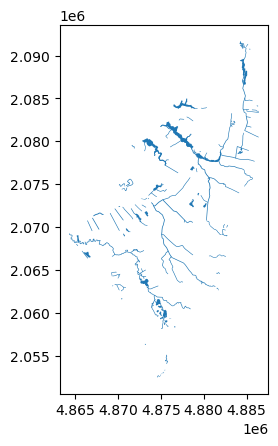

In [6]:
buffered  = agua.buffer(buffer_dist)   #Crea un buffer con el parámetro buffer_dist definido previamente
buffered.plot()

In [7]:
# Generar shapes que son tuplas geometría y valor de 1 en el buffer para rasterizar 
shapes = ((geom, 1) for geom in buffered)

# Rasterizar el DEM 
buf_rast = rasterize(
    shapes,
    out_shape=dem.shape, # Arreglo del mismo tamaño del DEM
    transform=transform,  # Matriz del DEM 
    fill=0,
    dtype="uint8"
)


buff = ruta_clean+"/bog_rio_buffered.tif" # Ruta para raster sin sumideros
with rasterio.open(buff, "w", **profile) as dst:
    dst.write(buf_rast, 1)

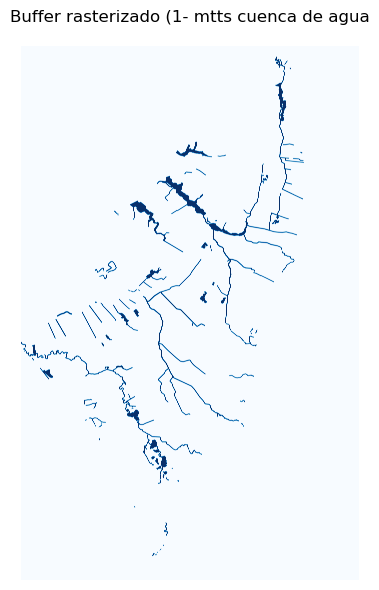

In [8]:
#  Visualizar el buffer rasterizado 
fig, ax = plt.subplots(figsize=(6,6))
show(buf_rast, transform=transform, ax=ax, cmap="Blues")
ax.set_title("Buffer rasterizado (1- mtts cuenca de agua")
ax.set_axis_off()
plt.tight_layout()
plt.show()

1.4. Ahora, tenemos en cuenta la elevación, calculamos la altura sobre el cauce más cercano para ver hasta donde alcanzaría el agua si el río sube cierto nivel

In [9]:
# Rutas donde exportaremos los resultados 
filled = ruta_clean+"/bog_filled.tif" # Ruta para raster sin sumideros
streams= ruta_clean+"/bog_str.tif"  # Ruta para raster de cauces
hand   = ruta_clean+"/bog_hand.tif" # Ruta para guardar la elevación sobre cauce 

In [11]:
# Fill raster: llenado para quitar sumideros
 
wbt = whitebox.WhiteboxTools()
wbt.fill_depressions(
    dem=dem_path,
    output=filled
)

./whitebox_tools --run="FillDepressions" --dem='/notebooks/trabajo_final/data/1_raw/MDT_Bogota_25pct.tif' --output='/notebooks/trabajo_final/data/2_clean/bog_filled.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding pit cells: 8%
Finding pit cells: 16%
Finding pit cells: 25%
Finding pit cells: 33%
Finding pit cells: 41%
Finding pit cells: 50%
Finding pit cells: 58%
Finding pit cells: 66%
Finding pit cells: 75%
Finding pit cells: 83%
Finding pit cells: 91%
Finding pit cells: 100%
Filling depressions: 0%
Filling depressions: 1%
Filling depressions: 2%
Filling depressions: 3%
Filling depressions: 4%
Filling depressions: 5%
Filling depressions: 6%
Filling depressions: 7%
Filling depressions: 8%
Filling depressions: 9%
Filling depressions: 10%
Filling depressions: 11%
Filling depressions: 12%
Filling depressions: 13%
Fi

0

In [12]:
# Rasterizo la capa de agua para poder calcular altura sobre el cauce más cercano 
geoms = agua.geometry[agua.geometry.notnull() & ~agua.geometry.is_empty]
shapes = ((geom, 1) for geom in geoms)

# Rasterizar al DEM 
aguarast = rasterize(
    shapes,
    out_shape=dem.shape, # Arreglo del mismo tamaño del DEM
    transform=transform,  # Matriz del DEM 
    fill=0,
    dtype="uint8"
)

with rasterio.open(streams, "w", **profile) as dst:
    dst.write(aguarast, 1)

In [13]:
wbt = whitebox.WhiteboxTools()

wbt.elevation_above_stream(
    dem=filled,
    streams=streams,
    output=hand
)

./whitebox_tools --run="ElevationAboveStream" --dem='/notebooks/trabajo_final/data/2_clean/bog_filled.tif' --streams='/notebooks/trabajo_final/data/2_clean/bog_str.tif' --output='/notebooks/trabajo_final/data/2_clean/bog_hand.tif' -v --compress_rasters=False

***********************************
* Welcome to ElevationAboveStream *
* Powered by WhiteboxTools        *
* www.whiteboxgeo.com             *
***********************************
Reading DEM data...
Reading streams data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow directions: 23%
Flow directions: 24%
F

0

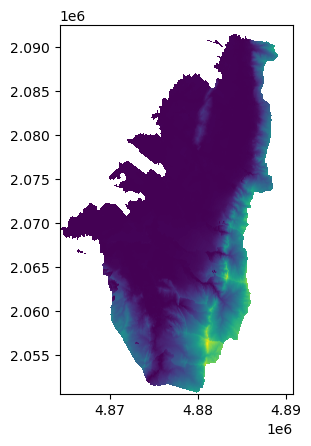

In [19]:
# Visualizar el resultado: Las áreas con valores bajos de HAND están más cerca de los arroyos y, por lo tanto, tienen un mayor riesgo de inundación.
hand_dem = rasterio.open(hand)
rasterio.plot.show(hand_dem);# Quick view of the DEM 

1.5. Combinar raster con buffer+ríos y capa HAND para determinar el riesgo de inundación 

Las áreas con mayor riesgo serán aquellas que tienen un valor HAND bajo y que están dentro del buffer de ríos.

In [14]:
# Este es el umbral de elevación alrededor de arroyos,10% pero se puede ajustar
hand_threshold_percentile = 10

In [15]:
with rasterio.open(hand) as hand_src, \
     rasterio.open(buff) as buffer_src:

    # Leer los datos como array
    hand_data = hand_src.read(1)
    buf_rast  = buffer_src.read(1) 

    # Manejar NoData y calcular el umbral dinámicamente, como porcentaje de HAND
    hand_data_valid = hand_data[hand_data != hand_src.nodata]
    calculated_hand_threshold = np.percentile(hand_data_valid, hand_threshold_percentile)
    print(f"Umbral HAND calculado ({hand_threshold_percentile}-vo percentil): {calculated_hand_threshold:.2f} metros")

    # Asegurar que NoData en el buffer se interprete como 'fuera del buffer'
    buf_rast[buf_rast == buffer_src.nodata] = 0

    # Riesgo de inundación:
    # Alto riesgo = (HAND bajo) AND (dentro del buffer de ríos)
    flood_risk_data = np.where(
        (hand_data <= calculated_hand_threshold) & (buf_rast == 1),
        1,  # Alto riesgo
        0   # Bajo riesgo
    ).astype(hand_src.profile['dtype'])

    # Preparar el perfil para el nuevo ráster
    profile = hand_src.profile.copy()
    profile.update(dtype=flood_risk_data.dtype, count=1, nodata=9999)

    # Definir la ruta donde se va a exportar el raster.tif con la data de riesgo de inundación 
    flood_path = ruta_clean+"/bog_flood_risk.tif"
         
    # Exportar el raster 
    with rasterio.open(flood_path, "w", **profile) as dest:
        dest.write(flood_risk_data, 1)

Umbral HAND calculado (10-vo percentil): 0.92 metros


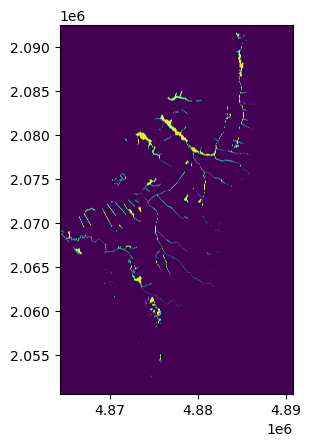

In [16]:
# Visualizar el resultado: 
frisk_dem = rasterio.open(flood_path)
rasterio.plot.show(frisk_dem);# Quick view of the DEM 

## Parte 2: Afectación a la población 

2.1. Traer la información de población

In [3]:
# Shape de población y vulnerabilidad que resultó de 1_data_preparation
pobsh  = ruta_clean+"/pob_vuln.shp"

# Leer la data 
pob = gpd.read_file(pobsh)
pob.head()

,COD_DANE_A,DPTO_CCDGO,MPIO_CCDGO,MPIO_CDPMP,CLAS_CCDGO,SETR_CCDGO,SETR_CCNCT,SECR_CCDGO,SECR_CCNCT,ZU_CCDGO,...,COD_DPTO,COD_MPIO,COD_DANE,CATEGORIA,LABEL,ipm,embarazo_a,reactivaci,_merge,geometry
0,1100110000000011010101,11,001,11001,1,000,110011000,00,11001100000,000,...,11,11001,1100110000000011010101,2.0,Vulnerabilidad baja,23.1,Vulnerabilidad media-baja,elegibilidad media,both,"POLYGON ((4880030.651 2064741.271, 4880030.668..."
1,1100110000000011010102,11,001,11001,1,000,110011000,00,11001100000,000,...,11,11001,1100110000000011010102,5.0,Vulnerabilidad media,20.8,Vulnerabilidad media-baja,elegibilidad media,both,"POLYGON ((4880144.24 2064800.487, 4880147.853 ..."
2,1100110000000011010103,11,001,11001,1,000,110011000,00,11001100000,000,...,11,11001,1100110000000011010103,3.0,Vulnerabilidad media-baja,9.7,Vulnerabilidad baja,elegibilidad media,both,"POLYGON ((4880283.067 2064569.668, 4880311.422..."
3,1100110000000011010104,11,001,11001,1,000,110011000,00,11001100000,000,...,11,11001,1100110000000011010104,4.0,Vulnerabilidad media-alta,5.6,Vulnerabilidad media-baja,elegibilidad media,both,"POLYGON ((4880011.303 2064647.161, 4880009.885..."
4,1100110000000011010105,11,001,11001,1,000,110011000,00,11001100000,000,...,11,11001,1100110000000011010105,3.0,Vulnerabilidad media-baja,19.6,Vulnerabilidad media,elegibilidad media,both,"POLYGON ((4880316.284 2064519.711, 4880337.676..."


In [24]:
# Confirmar el CRS 
pob.crs

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

2.2. Ahora se convertirá el raster de riesgo a vector, los 1, para poder sobreponer con manzanas (el raster de riesgo queda muy pesado y no se deja procesar)

In [ ]:
# Rutas 
flood_rast = ruta_clean + "/bog_flood_risk.tif"
flood_vect = ruta_clean + "/bog_flood_risk.shp"

# Abrir el raster de riesgo y leer la banda 
with rasterio.open(flood_rast) as src:
    arr = src.read(1)          
    transform = src.transform
    crs = src.crs

# Asegurarse arr es uint8 porque si no no funciona 
arr2 = arr.astype(np.uint8)

In [ ]:
# Mask: solo las celdas con 1 en riesgo 
mask = arr2 == 1


#Extraer polígonos y convertir a lista 
features = []
for geom, val in shapes(arr2, mask=mask, transform=transform):
    if val == 1:
        features.append({
            "properties": {"risk": int(val)},
            "geometry": geom
        })

# Crear un geodataframe a partir de la lista 
gdf = gpd.GeoDataFrame.from_features(features, crs=crs)

# Guardar el shapefile 
gdf.to_file(flood_vect)

<Axes: >

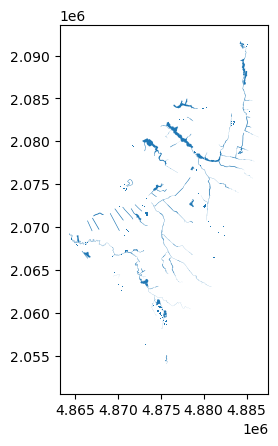

In [25]:
# Visualizar el resultado 
flood = gpd.read_file(flood_vect)
flood.plot()

2.3. Calcular el porcentaje de la manzana afectada, de ahí el porcentaje de población total en riesgo y el porcentaje de población vulnerable en riesgo 

In [26]:
#Verifico el CRS de flood 
flood.crs  # OK

<Projected CRS: EPSG:9377>
Name: MAGNA-SIRGAS 2018 / Origen-Nacional
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Colombia - onshore and offshore. Includes San Andres y Providencia, Malpelo Islands, Roncador Bank, Serrana Bank and Serranilla Bank.
- bounds: (-84.77, -4.23, -66.87, 15.51)
Coordinate Operation:
- name: Colombia Transverse Mercator
- method: Transverse Mercator
Datum: Marco Geocentrico Nacional de Referencia 2018
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [27]:
#Intersecto las manzanas de población con flood 
inter = gpd.overlay(pob, flood, how="intersection")

In [28]:
# Calcular el área de intersección 
inter["area_int"] = inter.geometry.area
inter.head()

,COD_DANE_A,DPTO_CCDGO,MPIO_CCDGO,MPIO_CDPMP,CLAS_CCDGO,SETR_CCDGO,SETR_CCNCT,SECR_CCDGO,SECR_CCNCT,ZU_CCDGO,...,COD_DANE,CATEGORIA,LABEL,ipm,embarazo_a,reactivaci,_merge,risk,geometry,area_int
0,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,1100110000000011030220,2.0,Vulnerabilidad baja,28.6,None,elegibilidad alta,both,1,"POLYGON ((4881183.691 2063148.929, 4881183.691...",3.993388
1,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,1100110000000011030220,2.0,Vulnerabilidad baja,28.6,None,elegibilidad alta,both,1,"POLYGON ((4881346.086 2063079.214, 4881346.086...",3.993388
2,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,1100110000000011030220,2.0,Vulnerabilidad baja,28.6,None,elegibilidad alta,both,1,"POLYGON ((4880894.559 2063073.619, 4880887.989...",1391.382766
3,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,1100110000000011030220,2.0,Vulnerabilidad baja,28.6,None,elegibilidad alta,both,1,"MULTIPOLYGON (((4881336.499 2063064.751, 48813...",3201.328568
4,1100110000000011040137,11,001,11001,1,000,110011000,00,11001100000,000,...,1100110000000011040137,2.0,Vulnerabilidad baja,66.7,None,elegibilidad media-baja,both,1,"MULTIPOLYGON (((4881631.243 2062813.638, 48816...",7.402417


In [31]:
# Ahora se hace un merge de intersección con la población 
inter = inter.merge(
    pob[["MNZ_ID", "TP27_PERSO", "area_m2", "ipm"]],
    on="MNZ_ID"
)

In [33]:
inter.head()

,COD_DANE_A,DPTO_CCDGO,MPIO_CCDGO,MPIO_CDPMP,CLAS_CCDGO,SETR_CCDGO,SETR_CCNCT,SECR_CCDGO,SECR_CCNCT,ZU_CCDGO,...,ipm_x,embarazo_a,reactivaci,_merge,risk,geometry,area_int,TP27_PERSO_y,area_m2_y,ipm_y
0,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,28.6,None,elegibilidad alta,both,1,"POLYGON ((4881183.691 2063148.929, 4881183.691...",3.993388,0.0,541731.599119,28.6
1,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,28.6,None,elegibilidad alta,both,1,"POLYGON ((4881346.086 2063079.214, 4881346.086...",3.993388,0.0,541731.599119,28.6
2,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,28.6,None,elegibilidad alta,both,1,"POLYGON ((4880894.559 2063073.619, 4880887.989...",1391.382766,0.0,541731.599119,28.6
3,1100110000000011030220,11,001,11001,1,000,110011000,00,11001100000,000,...,28.6,None,elegibilidad alta,both,1,"MULTIPOLYGON (((4881336.499 2063064.751, 48813...",3201.328568,0.0,541731.599119,28.6
4,1100110000000011040137,11,001,11001,1,000,110011000,00,11001100000,000,...,66.7,None,elegibilidad media-baja,both,1,"MULTIPOLYGON (((4881631.243 2062813.638, 48816...",7.402417,0.0,20021.399572,66.7


In [35]:
# Porcentaje de área de la manzana en riesgo 
inter["pct_area"] = inter["area_int"] / inter["area_m2_y"] * 100

In [37]:
# Total de población en riesgo 
inter["pop_afect"] = inter["TP27_PERSO_y"] * (inter["area_int"] / inter["area_m2_y"])

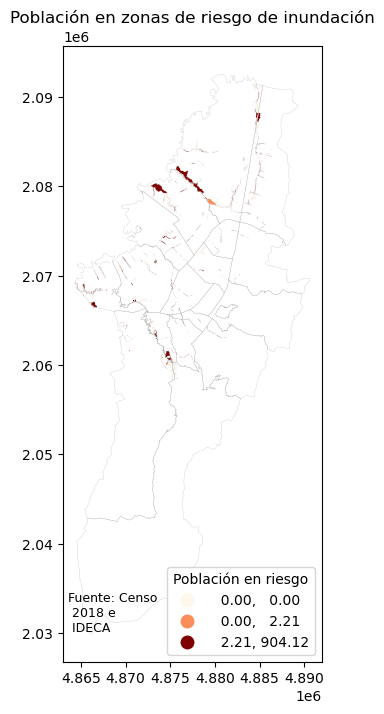

In [57]:
# Mapa de población por manzana en riesgo 
shp_path=root_folder+r"/poligonos-localidades.shp"
local   = gpd.read_file(shp_path)

fig, ax = plt.subplots(figsize=(8, 8))

inter.plot(
    column="pop_afect",
    scheme="Quantiles",  
    k=3,
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.01,
    legend=True,
     legend_kwds={
        "loc": "lower right",
        "title": "Población en riesgo"
    },
    ax=ax
)  

local1  = local.to_crs(inter.crs)  # Importar la de localidades para pegarlo ahí 
local1.boundary.plot(ax=ax,edgecolor='dimgray', linewidth=0.09, zorder=1)

ax.set_title("Población en zonas de riesgo de inundación")
ax.annotate("Fuente: Censo \n 2018 e \n IDECA", xy=(0.02, 0.05), xycoords="axes fraction", fontsize=9,)
plt.show()  
fig.savefig(ruta_mapa + r"/Poblacion_manzana_riesgo.png", dpi=300, bbox_inches='tight')

In [50]:
# Cálculo de la población en riesgo total
total_pop_afect = inter['pop_afect'].sum()
print(f"Población en riesgo total: {total_pop_afect:.0f} personas")

Población afectada total: 39573 personas


In [53]:
# Ahora, población pobre 
inter["pop_pobre"] = inter["TP27_PERSO_y"]*inter["ipm_y"]/100

# Total de población vulnerable en riesgo 
inter["pop_pobre_affect"] = inter["pop_pobre"] * (inter["area_int"] / inter["area_m2_y"])

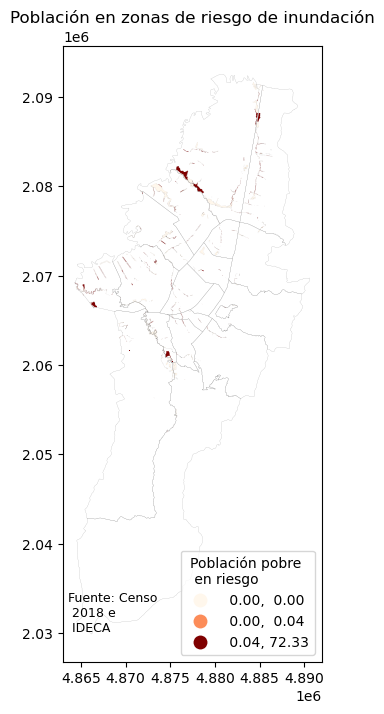

In [58]:
# Mapa de población pobre en riesgo 
fig, ax = plt.subplots(figsize=(8, 8))

inter.plot(
    column="pop_pobre_affect",
    scheme="Quantiles",  
    k=3,
    cmap="OrRd",
    edgecolor="black",
    linewidth=0.01,
    legend=True,
     legend_kwds={
        "loc": "lower right",
        "title": "Población pobre \n en riesgo"
    },
    ax=ax
)  

local1  = local.to_crs(inter.crs)  # Importar la de localidades para pegarlo ahí 
local1.boundary.plot(ax=ax,edgecolor='dimgray', linewidth=0.09, zorder=1)

ax.set_title("Población en zonas de riesgo de inundación")
ax.annotate("Fuente: Censo \n 2018 e \n IDECA", xy=(0.02, 0.05), xycoords="axes fraction", fontsize=9,)
plt.show()  
fig.savefig(ruta_mapa + r"/Poblacion_pobre_riesgo.png", dpi=300, bbox_inches='tight')

In [59]:
# Cálculo de la población en riesgo total
total_pop_afect = inter['pop_pobre_affect'].sum()
print(f"Población pobre en riesgo total: {total_pop_afect:.0f} personas")

Población pobre en riesgo total: 3185 personas
